# Baseline Dataset Overview

This notebook documents the baseline subset used for initial testing of different model configurations on the cross-view object correspondence task.

**How to use:** analysis scripts (in `src/scripts/data/`) are run on the remote VM to produce CSV files in `results/baseline_analysis/`. Transfer CSVs locally, then run this notebook to generate plots.

## 1. Data Selection


The baseline set is constructed from the full EgoExo4D relation-annotated data with the following pipeline:

1. **Extract UIDs** — Parse `{test,train,val}_egoexo_pairs.json` to collect all unique take UIDs (170 total).
2. **Classify scenarios** — Load `relations_{test,train,val}.json` and map each UID's scenario title to one of 8 canonical categories via keyword matching:
   `basketball`, `bike repair`, `cooking`, `music`, `health`, `dance`, `soccer`, `rock climbing`.
3. **Sample 10 takes per scenario** — Randomly sample 10 UIDs per category (seed=42). 5 of the 8 categories have data in the pairs files, yielding **50 takes**.
4. **Collect pairs** — Gather all associated 4-tuples `[ego_rgb, ego_mask, exo_rgb, exo_mask]` for each sampled UID.
5. **Mirror** — Swap ego/exo positions to produce the exo→ego variant.

**Output:**
- `baseline_egoexo_pairs.json` (29,671 pairs)
- `baseline_exoego_pairs.json` (29,671 pairs, mirrored)

Generation script: `src/scripts/data/generate_baseline_pairs.py`

## 2. Description of the Data


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (10, 5)})

ANALYSIS_DIR = Path("../results/baseline_analysis")
SCENARIO_ORDER = ["basketball", "bike repair", "cooking", "health", "music"]


### 2.1 Takes and Pairs per Scenario

df_takes head:
      scenario  n_takes
0   basketball       10
1  bike repair       10
2      cooking       10
3       health       10
4        music       10

df_pairs head:
      scenario  n_pairs
0   basketball      519
1  bike repair     2051
2      cooking    14642
3       health     7888
4        music     4571

df_summary head:
     scenario                              take_uid  n_pairs
0  basketball  058f9a7e-d7e8-415e-9827-272245422543       75
1  basketball  1789c39f-b302-48b4-9fa5-8716cfbfd43f       23
2  basketball  215844c3-63d3-4c8c-86f7-aeff2cf79764       42
3  basketball  2f86293e-823d-4e2d-8c54-2f888e2639ed       19
4  basketball  691b6dff-620e-4aab-8302-3a9045be33da       81


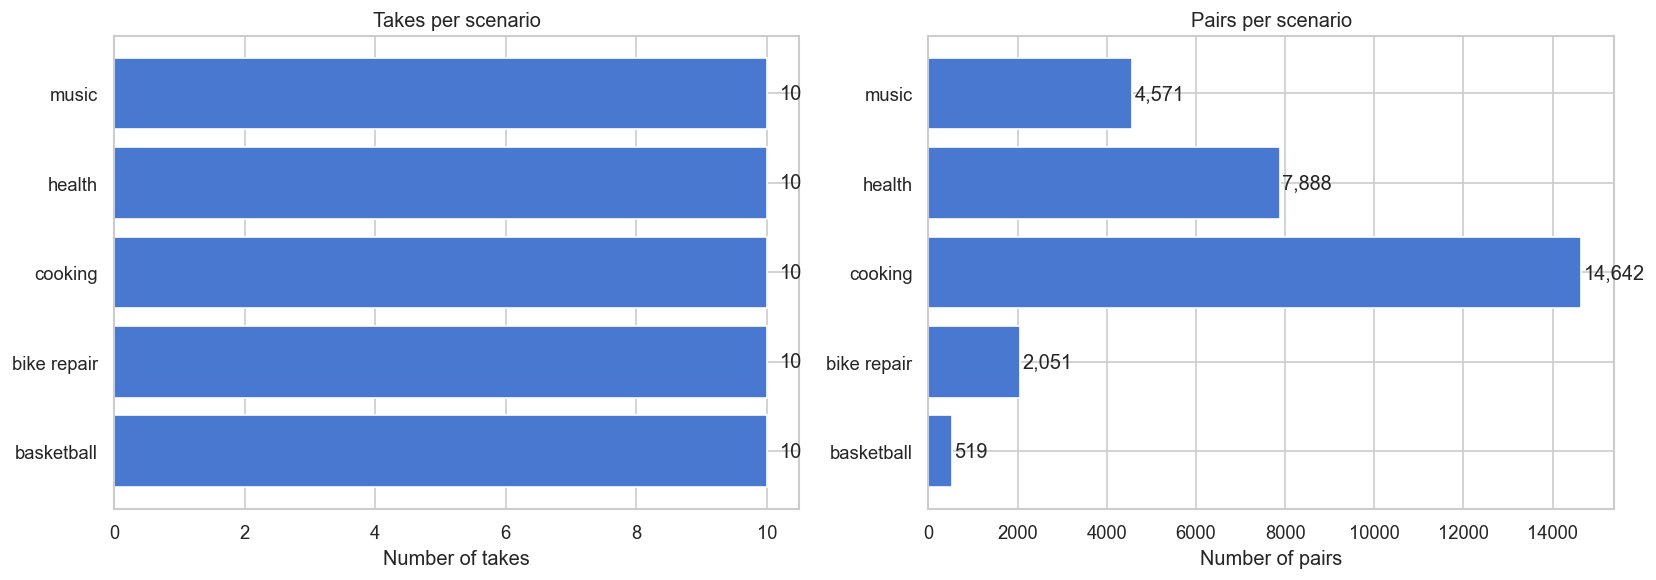

Total takes: 50
Total pairs: 29671


,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
basketball,10.0,52.0,33.0,19.0,32.0,42.0,68.0,127.0
bike repair,10.0,205.0,114.0,85.0,148.0,180.0,234.0,492.0
cooking,10.0,1464.0,1383.0,129.0,814.0,1312.0,1499.0,5063.0
health,10.0,789.0,845.0,66.0,92.0,590.0,1057.0,2293.0
music,10.0,457.0,274.0,39.0,329.0,452.0,691.0,807.0


,scenario,take_uid,n_pairs
0,basketball,058f9a7e-d7e8-415e-9827-272245422543,75
1,basketball,1789c39f-b302-48b4-9fa5-8716cfbfd43f,23
2,basketball,215844c3-63d3-4c8c-86f7-aeff2cf79764,42
3,basketball,2f86293e-823d-4e2d-8c54-2f888e2639ed,19
4,basketball,691b6dff-620e-4aab-8302-3a9045be33da,81
5,basketball,83b0fc4f-9a36-4dd7-9495-a68c9f82defe,127
6,basketball,98895ed3-7fc5-4dc0-ae9b-d808971e9334,32
7,basketball,ef2cad65-06b2-4b1a-8956-c387721d2051,33
8,basketball,f5ced826-d8ef-42c6-8e6e-2ba287da99d4,42
9,basketball,fcb6b025-6e41-4e97-b4b5-d5fdf0ebd3cb,45


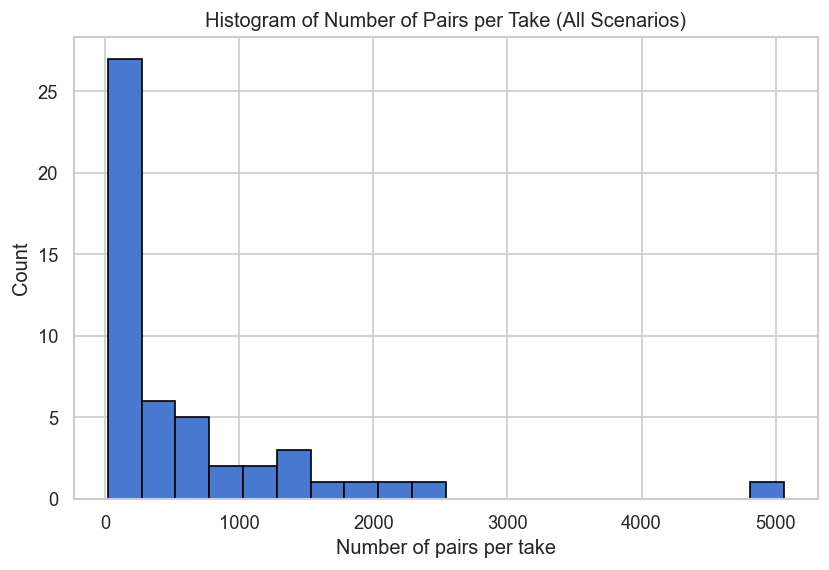

In [15]:
df_takes = pd.read_csv(ANALYSIS_DIR / "baseline_takes_per_scenario.csv")
df_pairs = pd.read_csv(ANALYSIS_DIR / "baseline_pairs_per_scenario.csv")
df_summary = pd.read_csv(ANALYSIS_DIR / "baseline_take_pair_summary.csv")

print("df_takes head:")
print(df_takes.head())
print("\ndf_pairs head:")
print(df_pairs.head())
print("\ndf_summary head:")
print(df_summary.head())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Takes per scenario
ax = axes[0]
df_takes_sorted = df_takes.set_index("scenario").loc[SCENARIO_ORDER]
ax.barh(df_takes_sorted.index, df_takes_sorted["n_takes"])
ax.set_xlabel("Number of takes")
ax.set_title("Takes per scenario")
for i, v in enumerate(df_takes_sorted["n_takes"]):
    ax.text(v + 0.2, i, str(v), va="center")

# Pairs per scenario
ax = axes[1]
df_pairs_sorted = df_pairs.set_index("scenario").loc[SCENARIO_ORDER]
ax.barh(df_pairs_sorted.index, df_pairs_sorted["n_pairs"])
ax.set_xlabel("Number of pairs")
ax.set_title("Pairs per scenario")
for i, v in enumerate(df_pairs_sorted["n_pairs"]):
    ax.text(v + 50, i, f"{v:,}", va="center")

plt.tight_layout()
plt.show()

print(f"Total takes: {df_takes['n_takes'].sum()}")
print(f"Total pairs: {df_pairs['n_pairs'].sum()}")
display(df_summary.groupby("scenario")["n_pairs"].describe().round(0))

# Display the number of pairs for each take across different scenarios,
pairs_per_take = df_summary.groupby(["scenario", "take_uid"])["n_pairs"].sum().reset_index()
display(pairs_per_take)
# Plot a histogram of number of pairs per take across all scenarios
plt.figure(figsize=(8, 5))
plt.hist(df_summary["n_pairs"], bins=20, edgecolor="black")
plt.xlabel("Number of pairs per take")
plt.ylabel("Count")
plt.title("Histogram of Number of Pairs per Take (All Scenarios)")
plt.show()

### 2.2 Mask Size Distribution

Distribution of mask area (in pixels) across all annotated frames, overall and per scenario.

df_mask head:
     scenario                              take_uid tracked_object  \
0  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
1  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
2  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
3  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
4  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   

         camera  frame  mask_area  
0  aria01_214-1    120      42669  
1  aria01_214-1    150      13535  
2  aria01_214-1    180      34492  
3  aria01_214-1    210      46919  
4  aria01_214-1    300      11198  


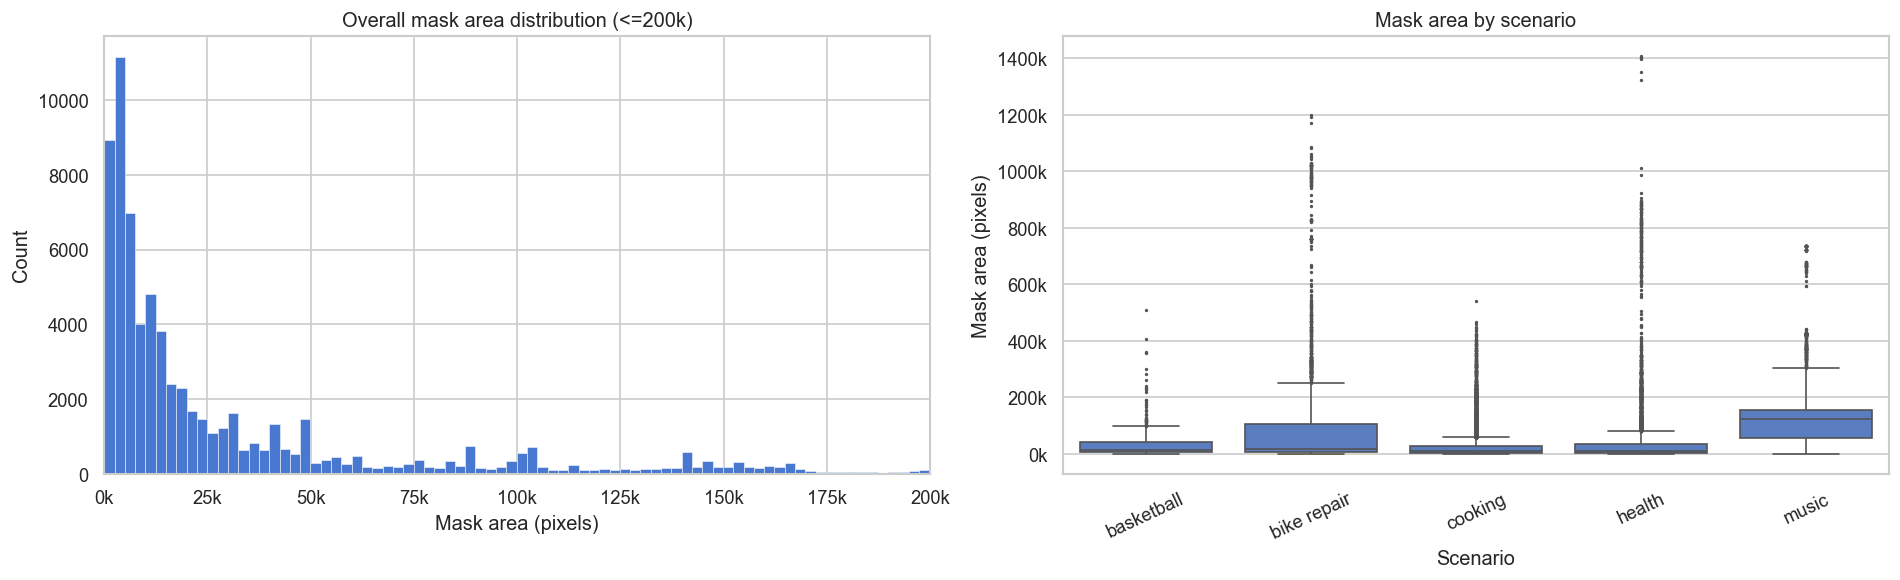

,scenario,count,mean,median,p05,p25,p75,p95
0,basketball,1276,28613.6,14791.5,2141.0,6654.0,43810.5,81459.0
1,bike repair,4654,84620.2,18101.5,1516.0,6442.5,104444.5,356597.5
2,cooking,42506,25244.9,10705.0,1033.0,3859.2,26584.8,103217.0
3,health,17646,36954.9,10220.0,769.0,3638.0,34760.5,133814.5
4,music,5925,128701.8,123782.0,17635.0,56473.0,155161.0,343826.6


In [17]:
df_mask = pd.read_csv(ANALYSIS_DIR / "baseline_mask_area_all.csv")

print("df_mask head:")
print(df_mask.head())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Overall histogram (restricted to mask_area <= 200k)
ax = axes[0]
ax.hist(df_mask[df_mask["mask_area"] <= 200_000]["mask_area"], bins=80, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Mask area (pixels)")
ax.set_ylabel("Count")
ax.set_title("Overall mask area distribution (<=200k)")
ax.set_xlim([0, 200_000])
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# Per-scenario box plot
ax = axes[1]
order = [s for s in SCENARIO_ORDER if s in df_mask["scenario"].unique()]
sns.boxplot(data=df_mask, x="scenario", y="mask_area", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Mask area (pixels)")
ax.set_title("Mask area by scenario")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(pd.read_csv(ANALYSIS_DIR / "baseline_mask_area_summary_by_scenario.csv"))




### 2.3 Object Movement (Displacement)

Total centroid displacement (sum of frame-to-frame Euclidean distances) for each tracked object, aggregated per scenario. Higher values indicate more dynamic objects that move significantly across frames.

df_disp head:
     scenario                              take_uid tracked_object  \
0  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
1  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
2  basketball  058f9a7e-d7e8-415e-9827-272245422543           hoop   
3  basketball  058f9a7e-d7e8-415e-9827-272245422543           hoop   
4  basketball  1789c39f-b302-48b4-9fa5-8716cfbfd43f     basketball   

         camera  total_displacement  
0  aria01_214-1            19057.56  
1         cam01            29454.59  
2  aria01_214-1             6403.50  
3         cam01              411.23  
4  aria01_214-1            11713.75  


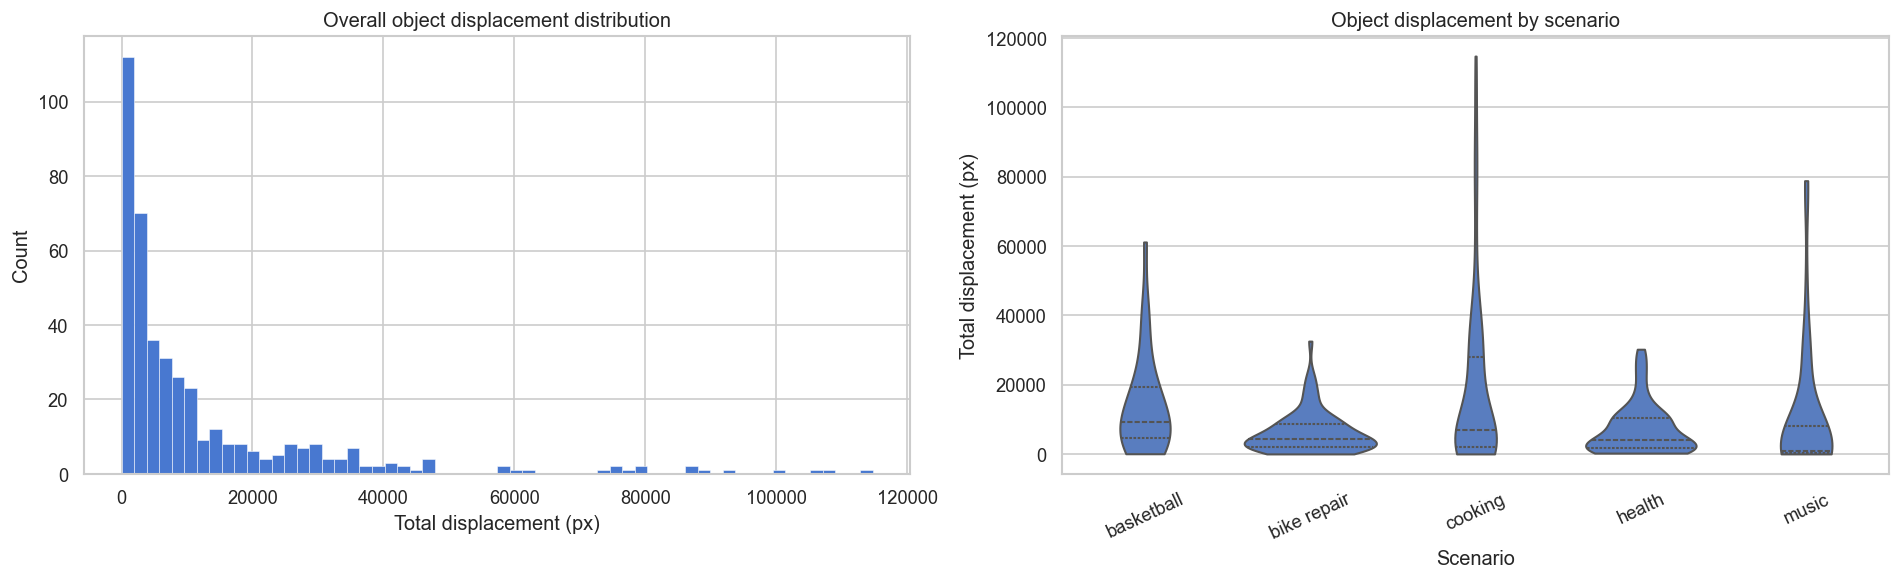

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
basketball,32.0,13925.8,14328.3,49.0,4536.1,9341.4,19213.5,61139.3
bike repair,76.0,6252.2,6033.8,0.0,1953.7,4340.6,8717.0,32538.9
cooking,173.0,18546.4,24702.4,0.0,2127.8,6794.3,27935.3,114767.1
health,98.0,7063.7,7235.6,232.4,1567.2,4133.8,10375.4,30197.2
music,41.0,10377.2,18849.9,6.3,235.8,879.1,8189.0,78824.9


In [18]:
df_disp = pd.read_csv(ANALYSIS_DIR / "baseline_object_displacement.csv")

print("df_disp head:")
print(df_disp.head())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
ax = axes[0]
ax.hist(df_disp["total_displacement"], bins=60, edgecolor="white", linewidth=0.3)
ax.set_xlabel("Total displacement (px)")
ax.set_ylabel("Count")
ax.set_title("Overall object displacement distribution")

# Per-scenario violin
ax = axes[1]
order = [s for s in SCENARIO_ORDER if s in df_disp["scenario"].unique()]
sns.violinplot(data=df_disp, x="scenario", y="total_displacement", order=order, ax=ax, cut=0, inner="quartile")
ax.set_xlabel("Scenario")
ax.set_ylabel("Total displacement (px)")
ax.set_title("Object displacement by scenario")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(df_disp.groupby("scenario")["total_displacement"].describe().round(1))

### 2.4 Object Size Change

Total area change (sum of frame-to-frame absolute area deltas) and average mask area for each tracked object. Large area changes can indicate scale variation due to camera motion, occlusion, or object transformation.

df_size head:
     scenario                              take_uid tracked_object  \
0  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
1  basketball  058f9a7e-d7e8-415e-9827-272245422543     basketball   
2  basketball  058f9a7e-d7e8-415e-9827-272245422543           hoop   
3  basketball  058f9a7e-d7e8-415e-9827-272245422543           hoop   
4  basketball  1789c39f-b302-48b4-9fa5-8716cfbfd43f     basketball   

         camera  total_area_change  average_area  
0  aria01_214-1          1275013.0      32685.31  
1         cam01           543956.0      17098.93  
2  aria01_214-1          2272232.0      56827.06  
3         cam01           161890.0      47879.93  
4  aria01_214-1          2250379.0      75893.57  


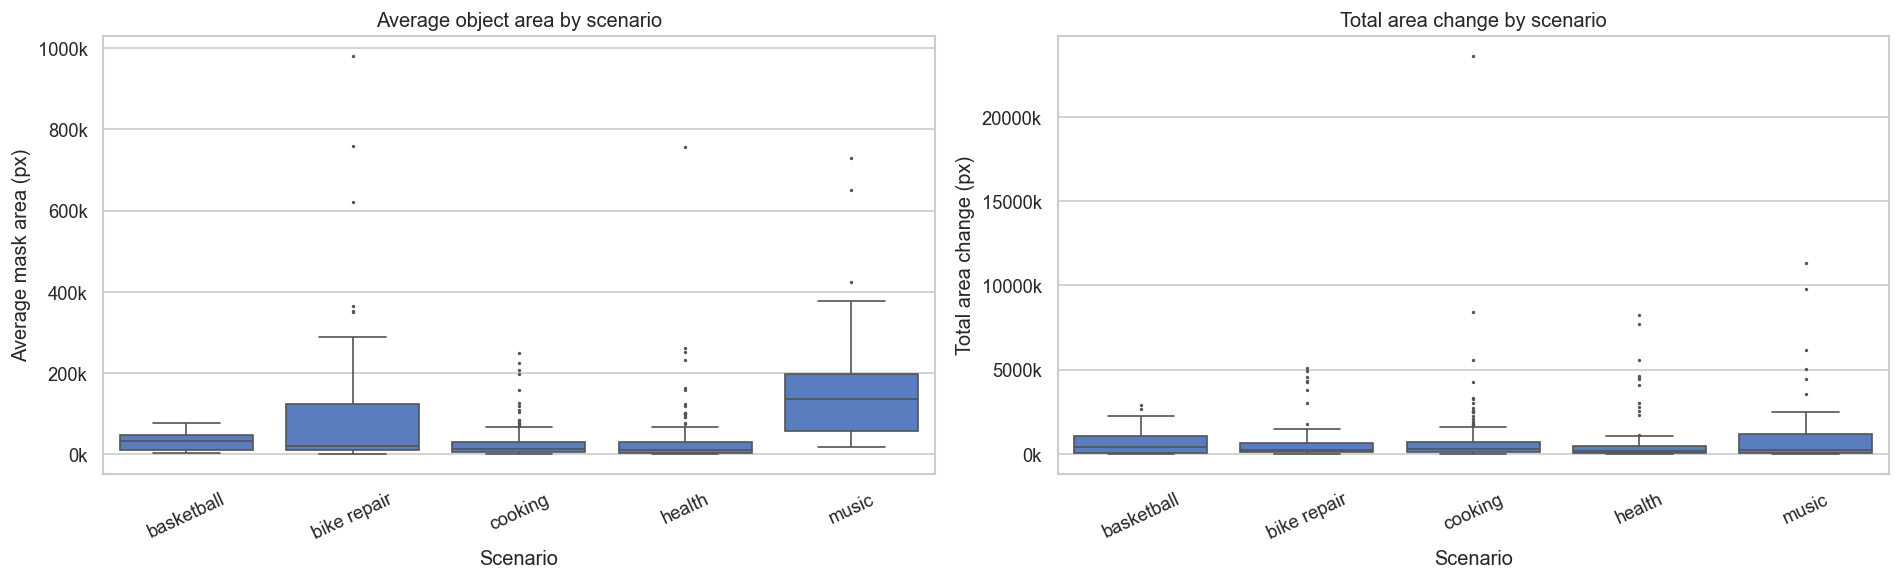

average_area                                                  \
                   count      mean       std      min      25%       50%   
scenario                                                                   
basketball          32.0   31143.0   21659.0   2386.0   9456.0   31511.0   
bike repair         76.0   92432.0  171032.0    865.0   8921.0   19341.0   
cooking            173.0   26479.0   39923.0    436.0   4938.0   12131.0   
health              98.0   39433.0   90164.0    286.0   3607.0   10687.0   
music               41.0  167256.0  157986.0  16777.0  57746.0  136807.0   

                                total_area_change                        \
                  75%       max             count       mean        std   
scenario                                                                  
basketball    47052.0   75894.0              32.0   700892.0   846516.0   
bike repair  123313.0  980884.0              76.0   709072.0  1222240.0   
cooking       30481.0  249162.0             173.0   779826.0  2025236.0   
health        29739.0  757106.0              98.0   719761.0  1525591.0   
music        196206.0  729040.0              41.0  1458652.0  2558457.0   

                                                                
                 min      25%       50%        75%         max  
scenario                                                        
basketball   12098.0  57228.0  407985.0  1090056.0   2900869.0  
bike repair      0.0  86357.0  230932.0   667642.0   5124630.0  
cooking          0.0  92194.0  308897.0   714054.0  23619593.0  
health        1508.0  56985.0  156844.0   456067.0   8246034.0  
music         1563.0  64502.0  243187.0  1176020.0  11324316.0

In [19]:
df_size = pd.read_csv(ANALYSIS_DIR / "baseline_object_size_change.csv")

print("df_size head:")
print(df_size.head())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average area per scenario
ax = axes[0]
order = [s for s in SCENARIO_ORDER if s in df_size["scenario"].unique()]
sns.boxplot(data=df_size, x="scenario", y="average_area", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Average mask area (px)")
ax.set_title("Average object area by scenario")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=25)

# Total area change per scenario
ax = axes[1]
sns.boxplot(data=df_size, x="scenario", y="total_area_change", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Total area change (px)")
ax.set_title("Total area change by scenario")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(df_size.groupby("scenario")[["average_area", "total_area_change"]].describe().round(0))

## 3. Other Statistics

Additional metrics relevant for understanding the cross-view object correspondence dataset.

### 3.1 Camera Coverage

Number of cameras per tracked object, split into ego (aria) and exo cameras. This shows how many viewpoints are available for cross-view correspondence per object.

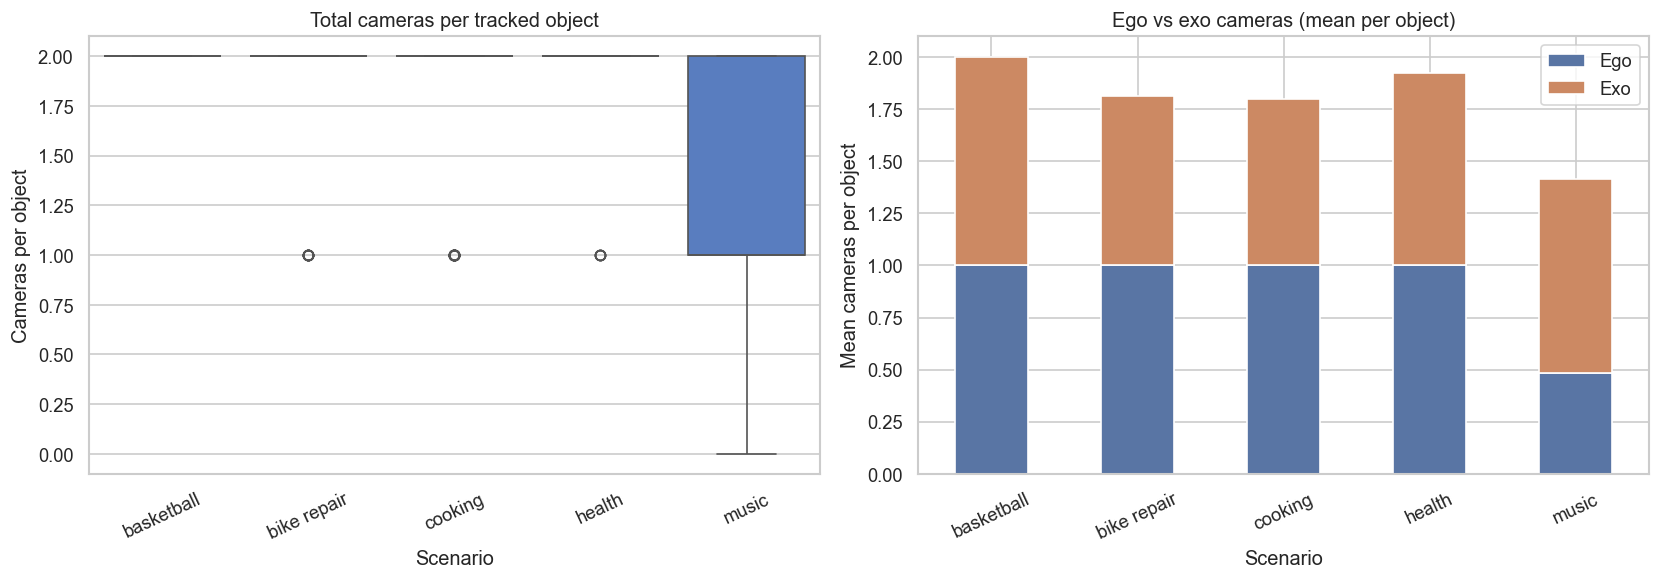

n_cameras                                      n_ego_cameras  \
                count  mean   std  min  25%  50%  75%  max         count   
scenario                                                                   
basketball       16.0  2.00  0.00  2.0  2.0  2.0  2.0  2.0          16.0   
bike repair      43.0  1.81  0.39  1.0  2.0  2.0  2.0  2.0          43.0   
cooking          99.0  1.80  0.40  1.0  2.0  2.0  2.0  2.0          99.0   
health           51.0  1.92  0.27  1.0  2.0  2.0  2.0  2.0          51.0   
music            29.0  1.41  0.63  0.0  1.0  1.0  2.0  2.0          29.0   

                   ...           n_exo_cameras                             \
             mean  ...  75%  max         count  mean   std  min  25%  50%   
scenario           ...                                                      
basketball   1.00  ...  1.0  1.0          16.0  1.00  0.00  1.0  1.0  1.0   
bike repair  1.00  ...  1.0  1.0          43.0  0.81  0.39  0.0  1.0  1.0   
cooking      1.00  ...  1.0  1.0          99.0  0.80  0.40  0.0  1.0  1.0   
health       1.00  ...  1.0  1.0          51.0  0.92  0.27  0.0  1.0  1.0   
music        0.48  ...  1.0  1.0          29.0  0.93  0.26  0.0  1.0  1.0   

                       
             75%  max  
scenario               
basketball   1.0  1.0  
bike repair  1.0  1.0  
cooking      1.0  1.0  
health       1.0  1.0  
music        1.0  1.0  

[5 rows x 24 columns]

In [6]:
df_cam = pd.read_csv(ANALYSIS_DIR / "baseline_camera_coverage.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total cameras per object
ax = axes[0]
order = [s for s in SCENARIO_ORDER if s in df_cam["scenario"].unique()]
sns.boxplot(data=df_cam, x="scenario", y="n_cameras", order=order, ax=ax)
ax.set_xlabel("Scenario")
ax.set_ylabel("Cameras per object")
ax.set_title("Total cameras per tracked object")
ax.tick_params(axis="x", rotation=25)

# Ego vs exo camera counts (stacked bar by scenario)
ax = axes[1]
cam_agg = df_cam.groupby("scenario")[["n_ego_cameras", "n_exo_cameras"]].mean().loc[order]
cam_agg.plot.bar(stacked=True, ax=ax, color=["#5975a4", "#cc8963"])
ax.set_xlabel("Scenario")
ax.set_ylabel("Mean cameras per object")
ax.set_title("Ego vs exo cameras (mean per object)")
ax.legend(["Ego", "Exo"], loc="upper right")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(df_cam.groupby("scenario")[["n_cameras", "n_ego_cameras", "n_exo_cameras"]].describe().round(2))

### 3.2 Track Temporal Statistics

Annotated frame count, temporal span, and density of object tracks. Temporal density measures how densely a track is annotated over its frame span (1.0 = every expected frame annotated). Sparse tracks may indicate objects leaving the frame or being occluded.

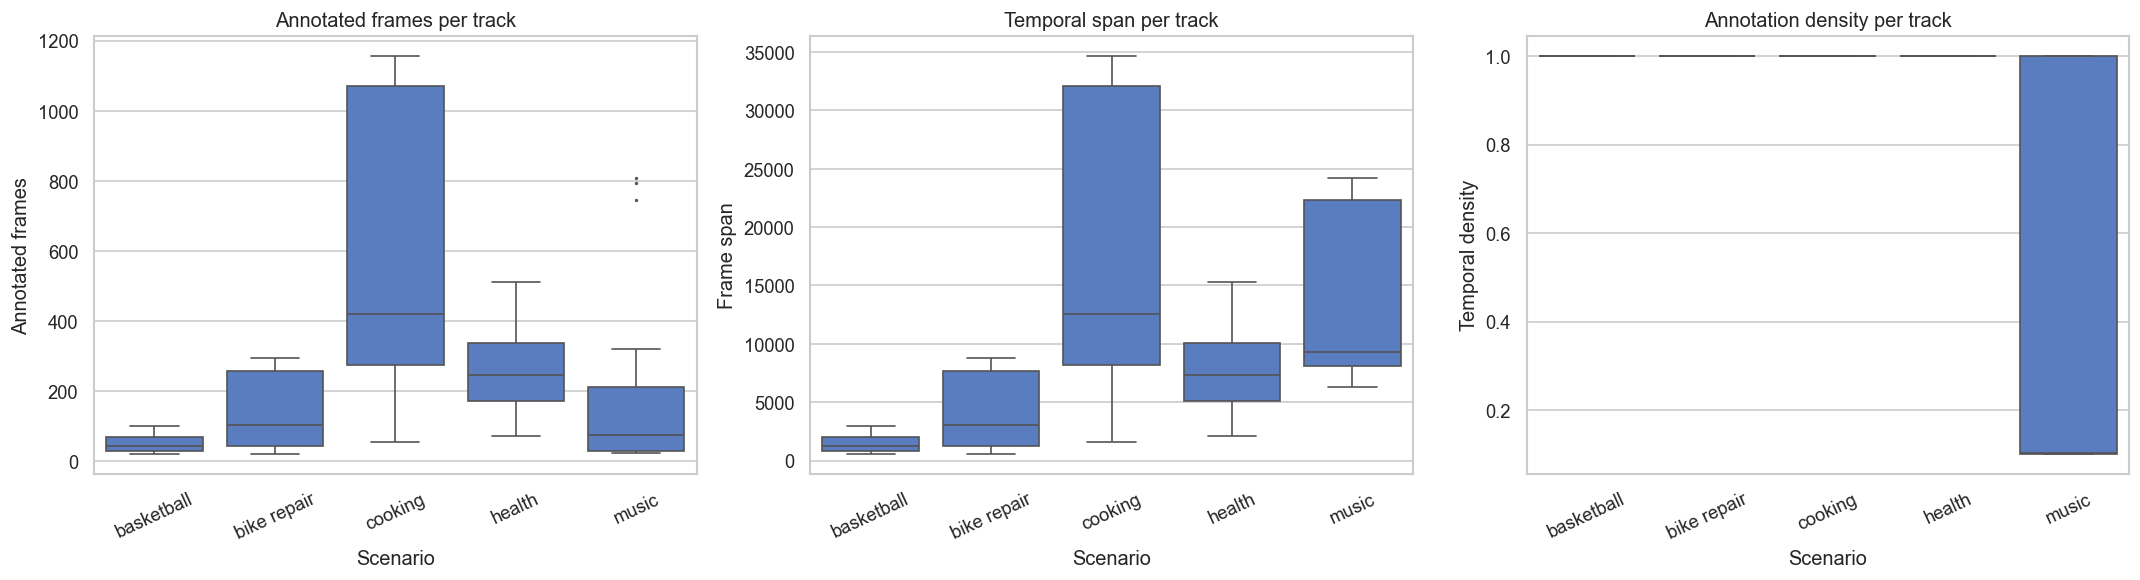

n_annotated_frames                                               \
                         count    mean     std   min     25%    50%     75%   
scenario                                                                      
basketball                32.0   49.25   27.30  20.0   27.75   42.5    68.0   
bike repair               78.0  131.06  100.14  20.0   42.00  103.0   258.0   
cooking                  178.0  530.05  368.26  55.0  273.00  419.0  1071.0   
health                    98.0  260.56  126.97  71.0  171.00  245.0   337.0   
music                     41.0  149.32  201.04  22.0   28.00   75.0   212.0   

                    frame_span            ...                    \
                max      count      mean  ...      75%      max   
scenario                                  ...                     
basketball    101.0       32.0   1447.50  ...   2010.0   3000.0   
bike repair   295.0       78.0   3901.92  ...   7710.0   8820.0   
cooking      1156.0      178.0  15871.52  ...  32100.0  34650.0   
health        512.0       98.0   7786.84  ...  10080.0  15330.0   
music         807.0       41.0  13919.27  ...  22320.0  24180.0   

            temporal_density                                       
                       count  mean   std  min  25%  50%  75%  max  
scenario                                                           
basketball              32.0  1.00  0.00  1.0  1.0  1.0  1.0  1.0  
bike repair             78.0  1.00  0.00  1.0  1.0  1.0  1.0  1.0  
cooking                178.0  1.00  0.00  1.0  1.0  1.0  1.0  1.0  
health                  98.0  1.00  0.00  1.0  1.0  1.0  1.0  1.0  
music                   41.0  0.37  0.41  0.1  0.1  0.1  1.0  1.0  

[5 rows x 24 columns]

In [7]:
df_temp = pd.read_csv(ANALYSIS_DIR / "baseline_track_temporal_stats.csv")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

order = [s for s in SCENARIO_ORDER if s in df_temp["scenario"].unique()]

# Number of annotated frames
ax = axes[0]
sns.boxplot(data=df_temp, x="scenario", y="n_annotated_frames", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Annotated frames")
ax.set_title("Annotated frames per track")
ax.tick_params(axis="x", rotation=25)

# Frame span
ax = axes[1]
sns.boxplot(data=df_temp, x="scenario", y="frame_span", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Frame span")
ax.set_title("Temporal span per track")
ax.tick_params(axis="x", rotation=25)

# Temporal density
ax = axes[2]
sns.boxplot(data=df_temp, x="scenario", y="temporal_density", order=order, ax=ax, fliersize=1)
ax.set_xlabel("Scenario")
ax.set_ylabel("Temporal density")
ax.set_title("Annotation density per track")
ax.tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

display(df_temp.groupby("scenario")[["n_annotated_frames", "frame_span", "temporal_density"]].describe().round(2))

### 3.3 Object Diversity per Take

Number of distinct tracked objects per take. Higher object diversity means the model must handle multi-object correspondence within a single scene.

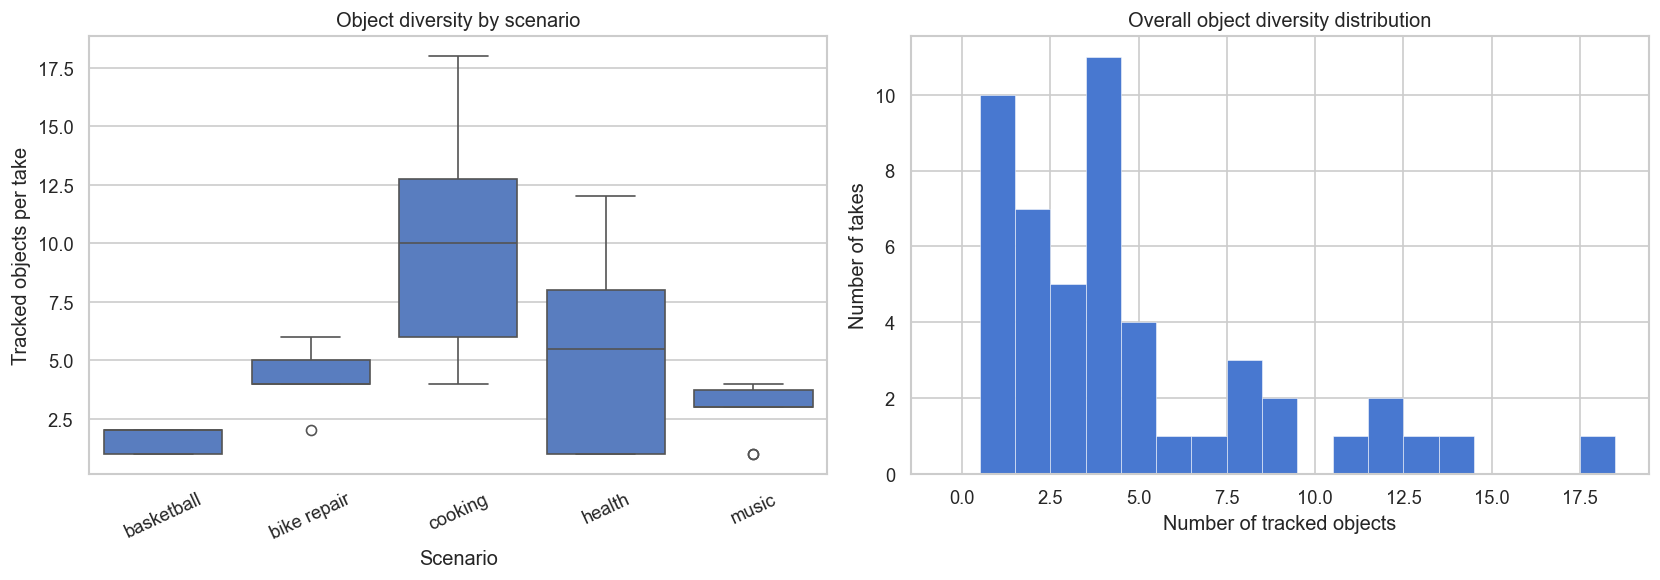

,count,mean,std,min,25%,50%,75%,max
scenario,,,,,,,,
basketball,10.0,1.6,0.5,1.0,1.0,2.0,2.0,2.0
bike repair,10.0,4.3,1.1,2.0,4.0,4.0,5.0,6.0
cooking,10.0,9.9,4.6,4.0,6.0,10.0,12.8,18.0
health,10.0,5.1,4.0,1.0,1.0,5.5,8.0,12.0
music,10.0,2.9,1.1,1.0,3.0,3.0,3.8,4.0


In [8]:
df_div = pd.read_csv(ANALYSIS_DIR / "baseline_take_object_diversity.csv")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = [s for s in SCENARIO_ORDER if s in df_div["scenario"].unique()]

# Box plot of object count per scenario
ax = axes[0]
sns.boxplot(data=df_div, x="scenario", y="n_tracked_objects", order=order, ax=ax)
ax.set_xlabel("Scenario")
ax.set_ylabel("Tracked objects per take")
ax.set_title("Object diversity by scenario")
ax.tick_params(axis="x", rotation=25)

# Histogram of overall object counts
ax = axes[1]
ax.hist(df_div["n_tracked_objects"], bins=range(0, df_div["n_tracked_objects"].max() + 2),
        edgecolor="white", linewidth=0.3, align="left")
ax.set_xlabel("Number of tracked objects")
ax.set_ylabel("Number of takes")
ax.set_title("Overall object diversity distribution")

plt.tight_layout()
plt.show()

display(df_div.groupby("scenario")["n_tracked_objects"].describe().round(1))

# 4. LM-EEC Results

In [ ]:
# LM-EEC baseline results EDA
LMEEC_DIR = Path("../results/lmeec-baseline")

# Load detailed results for both directions
df_egoexo = pd.read_csv(LMEEC_DIR / "detailed_results_ego-exo.csv")
df_exoego = pd.read_csv(LMEEC_DIR / "detailed_results_exo-ego.csv")

# Combine with direction label
df_egoexo = df_egoexo.assign(direction="ego-exo")
df_exoego = df_exoego.assign(direction="exo-ego")
df_all = pd.concat([df_egoexo, df_exoego], ignore_index=True)

# Parse numeric columns (some may be read as strings when empty)
for col in ["iou", "shape_acc", "location_score", "gt_area", "pred_area"]:
    df_all[col] = pd.to_numeric(df_all[col], errors="coerce")

# Rows with valid IOU (both gt and pred exist)
df_with_iou = df_all.dropna(subset=["iou"])

### 4.1 Distribution of IOU across all takes

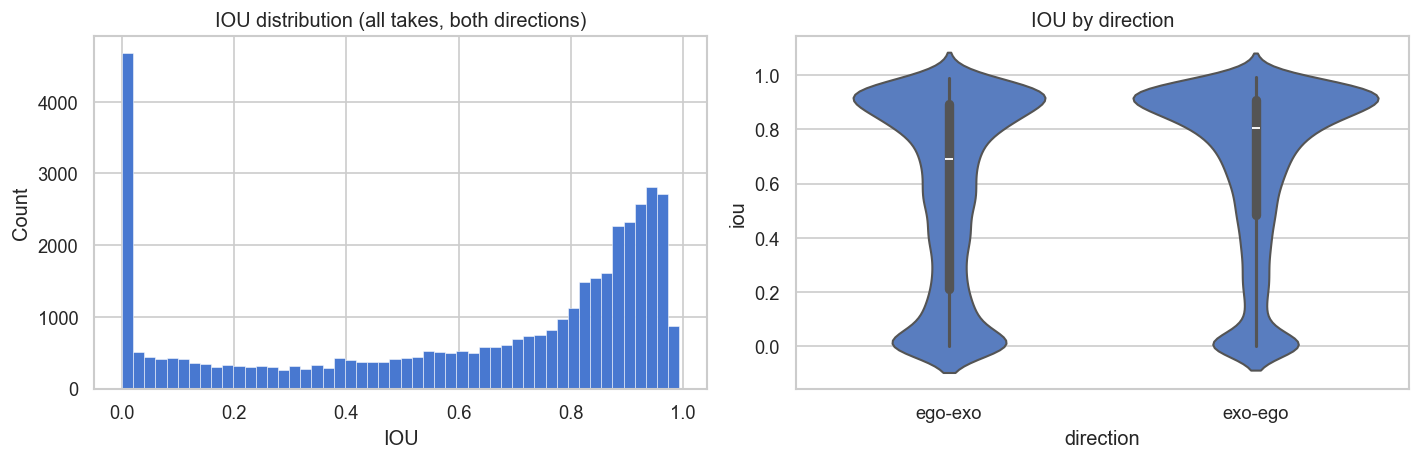

IOU stats: mean=0.616, median=0.762, std=0.340


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# Histogram
axes[0].hist(df_with_iou["iou"], bins=50, edgecolor="white", linewidth=0.3)
axes[0].set_xlabel("IOU")
axes[0].set_ylabel("Count")
axes[0].set_title("IOU distribution (all takes, both directions)")
# By direction
sns.violinplot(data=df_with_iou, x="direction", y="iou", ax=axes[1])
axes[1].set_title("IOU by direction")
plt.tight_layout()
plt.show()
print(f"IOU stats: mean={df_with_iou['iou'].mean():.3f}, median={df_with_iou['iou'].median():.3f}, std={df_with_iou['iou'].std():.3f}")

### 4.2 Distribution of other metrics across all takes

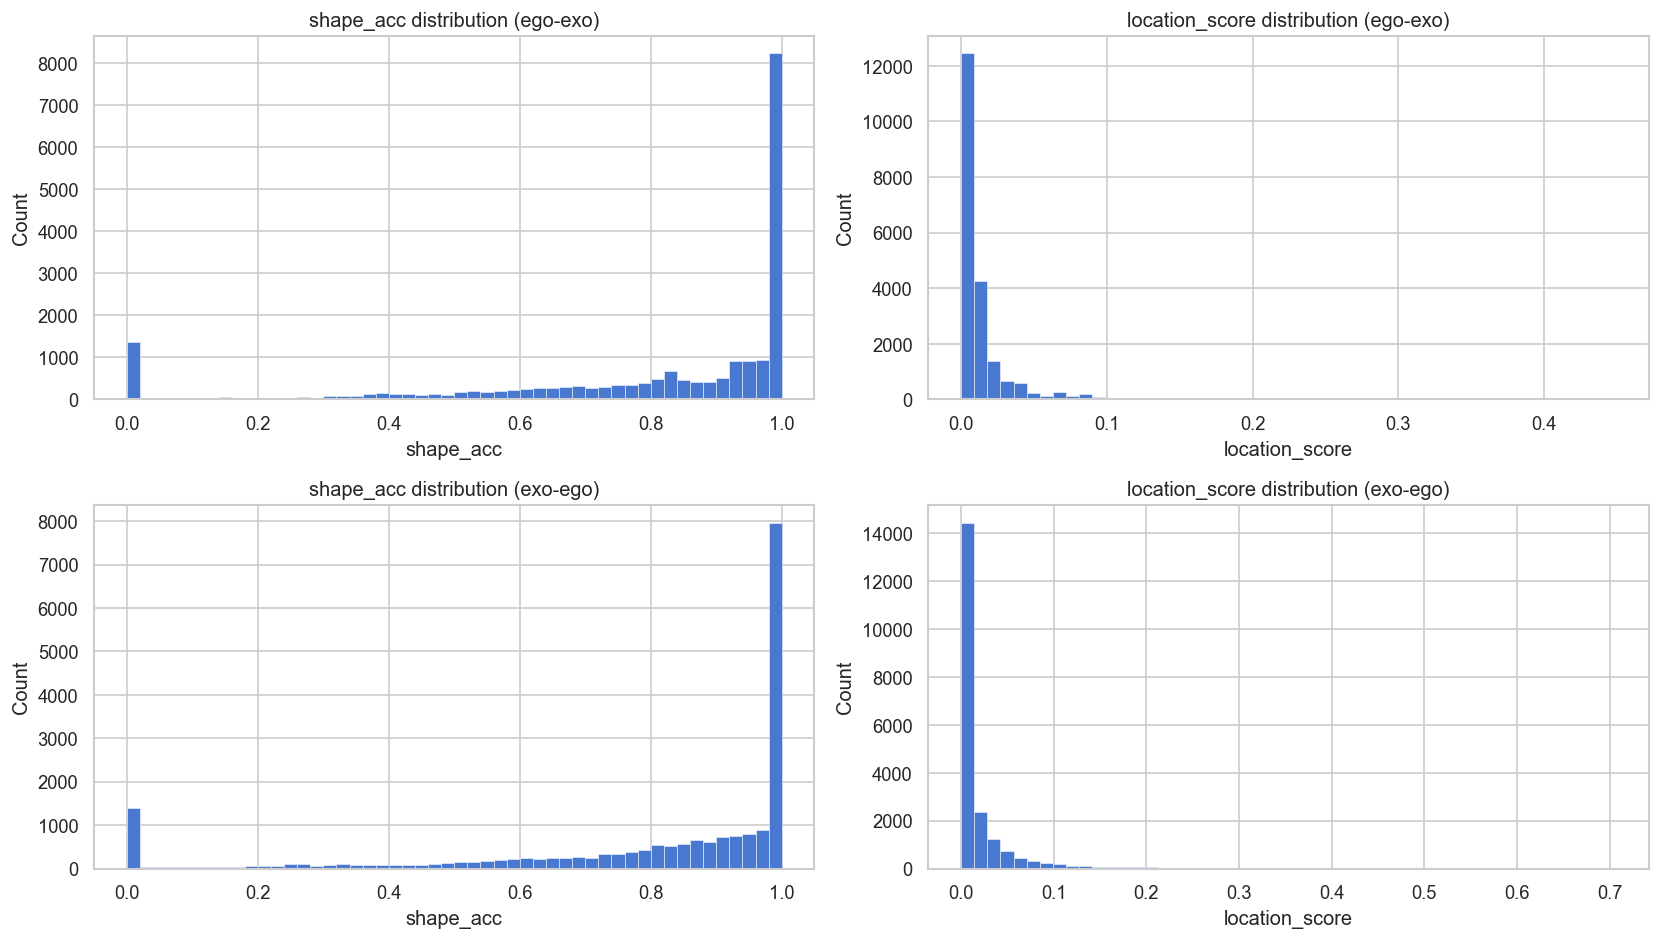

Existence accuracy (per row): 0.9985119047619048


In [14]:
metrics = ["shape_acc", "location_score"]
directions = ["ego-exo", "exo-ego"]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, direction in enumerate(directions):
    df_dir = df_with_iou[df_with_iou["direction"] == direction]
    for j, metric in enumerate(metrics):
        valid = df_dir[metric].dropna()
        ax = axes[i, j]
        if len(valid) > 0:
            ax.hist(valid, bins=50, edgecolor="white", linewidth=0.3)
        ax.set_xlabel(metric)
        ax.set_ylabel("Count")
        ax.set_title(f"{metric} distribution ({direction})")

plt.tight_layout()
plt.show()

print("Existence accuracy (per row):", df_all["existence_acc"].mean())

### 4.3 Infer scenario from object_id and IOU stratified by scenario

Scenario is inferred from object_id using keyword matching (from `_baseline_common.SCENARIO_KEYWORDS`). Objects not matching any keyword fall back to take-level scenario from baseline metadata.

In [10]:
# Scenario keywords from baseline (cooking, music, health, basketball, bike repair, etc.)
SCENARIO_KEYWORDS = {
    "basketball": ["basketball", "drills", "layup", "mikan", "jump shooting", "mid-range", "reverse layup", "hoop"],
    "bike repair": ["wheel", "tire", "flat", "tube", "chain", "lubricate", "derailleur", "derailueur", "bike", "bicycle", "pedal", "fork", "grip", "wrench", "pump"],
    "cooking": ["cooking", "making", "omelet", "scrambled", "eggs", "noodles", "pasta", "salad", "greek", "cucumber", "tomato", "sesame", "ginger", "milk tea", "chai", "coffee", "latte", "pan", "skillet", "bowl", "plate", "knife", "fork", "spoon", "board", "saucepan", "noodles", "egg", "garlic", "celery", "carrot", "pepper", "kettle", "mug", "butter", "pizza", "leek", "turmeric", "oyster", "sugar", "spaghetti", "strainer", "spatula", "scissor", "napkin", "towel", "cloth"],
    "music": ["piano", "violin", "guitar", "suzuki", "playing", "scales", "arpeggios", "freeplaying", "sheet music"],
    "health": ["first aid", "cpr", "covid", "antigen", "rapid", "test", "swab", "buffer", "extraction", "sterile", "disposable", "flowflex", "instruction manual", "water bottle"],
    "dance": ["dance", "dancing"],
    "soccer": ["soccer", "football"],
    "rock climbing": ["rock climbing", "climbing"],
}

def infer_scenario_from_object_id(obj_id: str) -> str | None:
    """Map object_id to scenario via keyword matching. Returns None if no match."""
    s = str(obj_id).lower().strip()
    s = s.rsplit("_", 1)[0] if s and s[-1].isdigit() else s  # strip _0 suffix
    for scenario, keywords in SCENARIO_KEYWORDS.items():
        for kw in keywords:
            if kw in s:
                return scenario
    return None

# Load take->scenario from baseline (fallback when object_id doesn't match)
df_take_scenario = pd.read_csv(ANALYSIS_DIR / "baseline_take_object_diversity.csv")[["take_uid", "scenario"]].drop_duplicates()
take_to_scenario = dict(zip(df_take_scenario["take_uid"], df_take_scenario["scenario"]))

def get_scenario(row):
    s = infer_scenario_from_object_id(row["object_id"])
    if s:
        return s
    return take_to_scenario.get(row["take_id"], "other")

df_with_iou["scenario"] = df_with_iou.apply(get_scenario, axis=1)

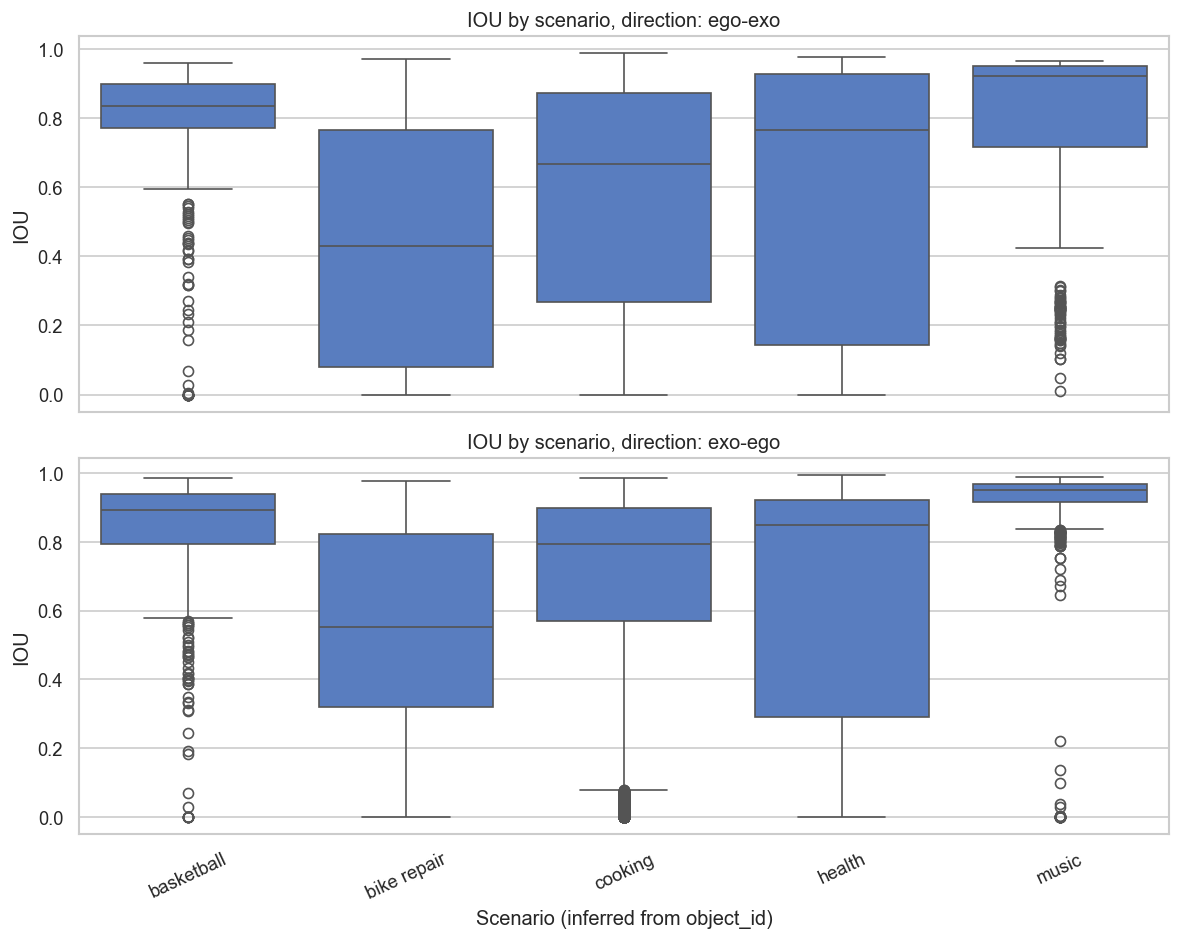

In [17]:
if "direction" not in df_with_iou.columns:
    df_with_iou["direction"] = None

order = [s for s in SCENARIO_ORDER if s in df_with_iou["scenario"].unique()]
order = order + [s for s in df_with_iou["scenario"].unique() if s not in order]

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

for idx, direction in enumerate(["ego-exo", "exo-ego"]):
    df_dir = df_with_iou[df_with_iou["direction"] == direction] if df_with_iou["direction"].notna().any() else df_with_iou.copy()
    sns.boxplot(
        data=df_dir, 
        x="scenario", 
        y="iou", 
        order=order,
        ax=axes[idx]
    )
    axes[idx].set_xlabel("Scenario (inferred from object_id)")
    axes[idx].set_ylabel("IOU")
    axes[idx].set_title(f"IOU by scenario, direction: {direction}")
    axes[idx].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()

### 4.4 GT area vs IOU and Pred area vs IOU

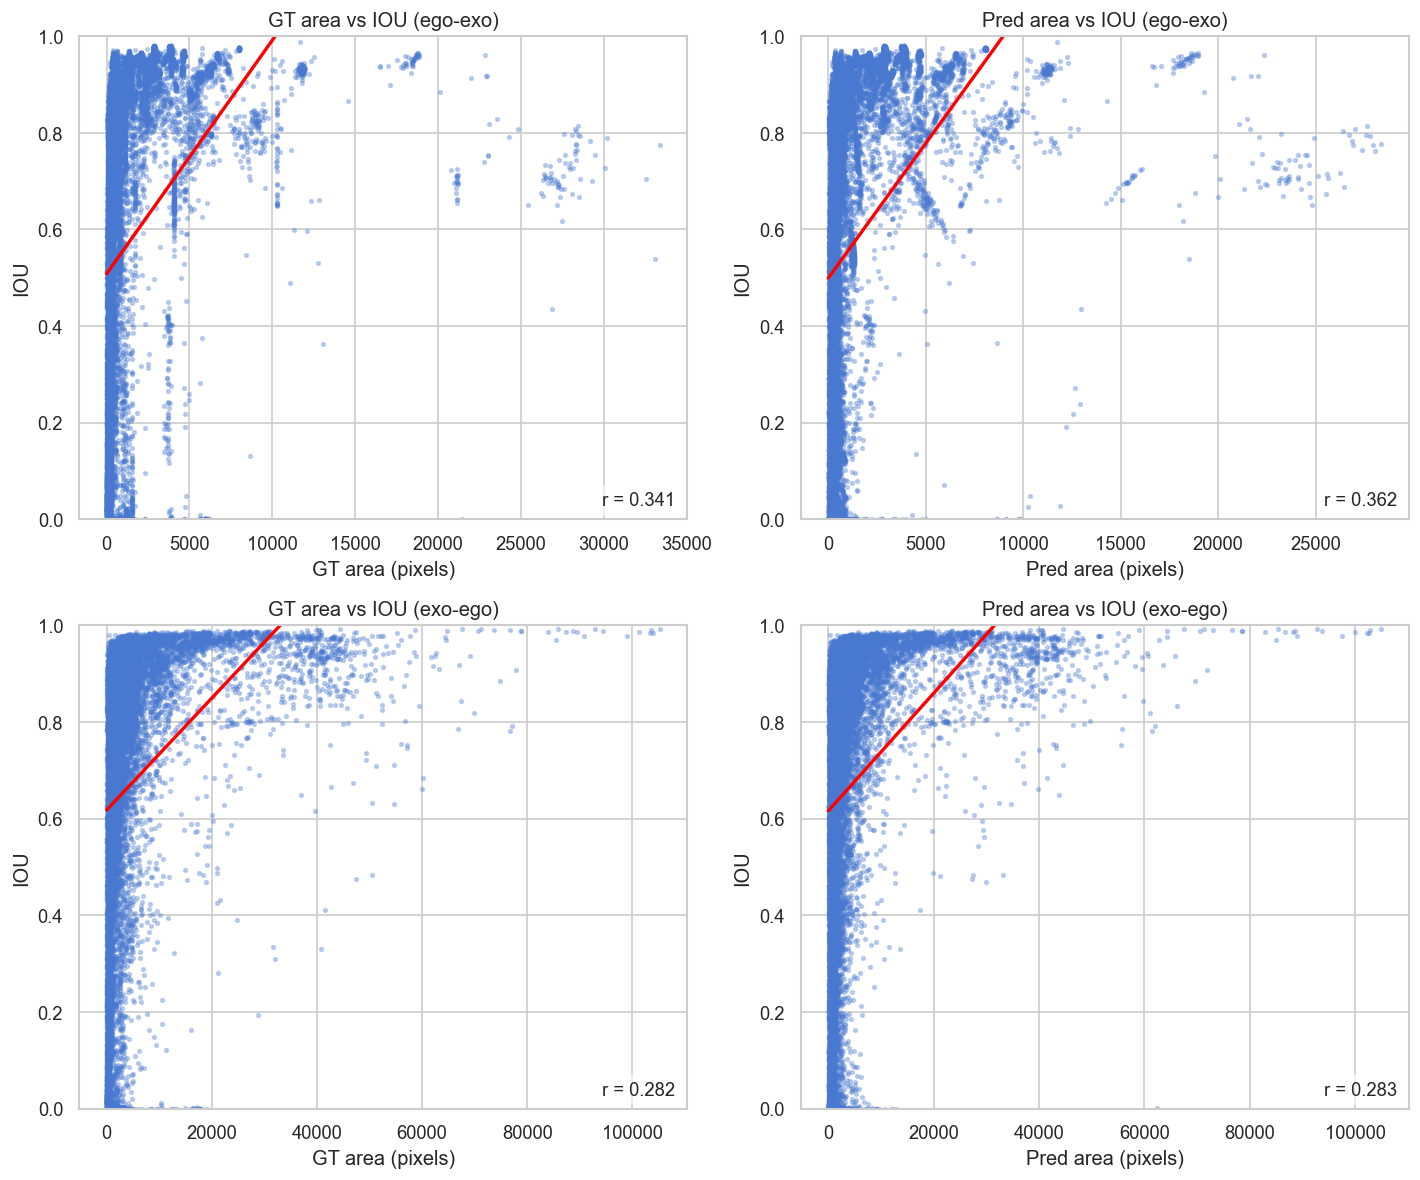

In [23]:
# Plot gt_area vs IOU and pred_area vs IOU, split by experiment direction, with trendlines and correlation indicators
from scipy.stats import pearsonr
import numpy as np

valid = df_with_iou.dropna(subset=["gt_area", "pred_area"])

directions = ["ego-exo", "exo-ego"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for row_idx, direction in enumerate(directions):
    if "direction" in valid.columns and valid["direction"].notna().any():
        v = valid[valid["direction"] == direction]
    else:
        v = valid.copy()
    # GT area vs IOU
    x = v["gt_area"].values
    y = v["iou"].values
    ax = axes[row_idx, 0]
    ax.scatter(x, y, alpha=0.3, s=5)
    # Trendline
    if len(x) > 1:
        coeffs = np.polyfit(x, y, 1)
        poly_fn = np.poly1d(coeffs)
        xs = np.linspace(np.nanmin(x), np.nanmax(x), 100)
        ax.plot(xs, poly_fn(xs), color="red", lw=2, label="Trendline")
        # Correlation
        r, p = pearsonr(x, y)
        ax.annotate(f"r = {r:.3f}", xy=(0.98, 0.02), xycoords="axes fraction", ha="right", va="bottom", fontsize=11,
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
    ax.set_xlabel("GT area (pixels)")
    ax.set_ylabel("IOU")
    ax.set_title(f"GT area vs IOU ({direction})")
    # Cap y-axis at 1.0
    ax.set_ylim(0, 1.0)

    # Pred area vs IOU
    x2 = v["pred_area"].values
    y2 = v["iou"].values
    ax2 = axes[row_idx, 1]
    ax2.scatter(x2, y2, alpha=0.3, s=5)
    # Trendline
    if len(x2) > 1:
        coeffs2 = np.polyfit(x2, y2, 1)
        poly_fn2 = np.poly1d(coeffs2)
        xs2 = np.linspace(np.nanmin(x2), np.nanmax(x2), 100)
        ax2.plot(xs2, poly_fn2(xs2), color="red", lw=2, label="Trendline")
        # Correlation
        r2, p2 = pearsonr(x2, y2)
        ax2.annotate(f"r = {r2:.3f}", xy=(0.98, 0.02), xycoords="axes fraction", ha="right", va="bottom", fontsize=11,
                     bbox=dict(facecolor='white', edgecolor='none', alpha=0.6))
    ax2.set_xlabel("Pred area (pixels)")
    ax2.set_ylabel("IOU")
    ax2.set_title(f"Pred area vs IOU ({direction})")
    # Cap y-axis at 1.0
    ax2.set_ylim(0, 1.0)

plt.tight_layout()
plt.show()

### 4.5 Object size classes by GT area and IOU stratified by size

Define 3 size classes (small, medium, large) by tertiles of gt_area among rows with valid IOU.

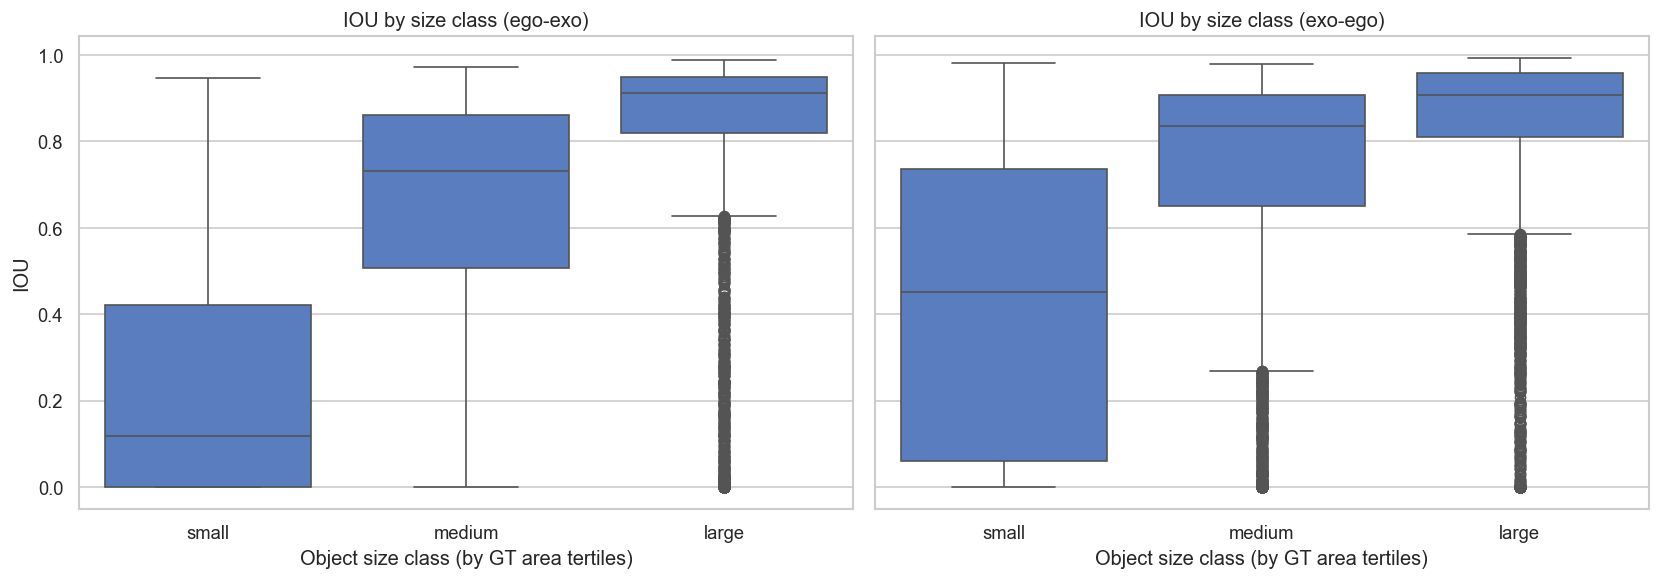

Direction: ego-exo | Size class boundaries: small <= 205, medium <= 836, large > 836 (gt_area pixels)
Direction: exo-ego | Size class boundaries: small <= 715, medium <= 2514, large > 2514 (gt_area pixels)


In [26]:
# Define 3 object size classes by gt_area tertiles separately for each direction
directions = df_with_iou["direction"].unique()
size_class_bounds = {}

fig, axes = plt.subplots(1, len(directions), figsize=(7 * len(directions), 5), sharey=True)

if len(directions) == 1:
    axes = [axes]

for i, direction in enumerate(directions):
    df_dir = df_with_iou[df_with_iou["direction"] == direction]
    valid_gt = df_dir.dropna(subset=["gt_area"])
    q33 = valid_gt["gt_area"].quantile(1 / 3)
    q66 = valid_gt["gt_area"].quantile(2 / 3)
    size_class_bounds[direction] = (q33, q66)

    def size_class(area):
        if pd.isna(area):
            return np.nan
        if area <= q33:
            return "small"
        if area <= q66:
            return "medium"
        return "large"

    size_col = f"size_class_{direction}"
    df_with_iou.loc[df_with_iou["direction"] == direction, size_col] = df_with_iou.loc[df_with_iou["direction"] == direction, "gt_area"].apply(size_class)

    valid_size = df_with_iou[df_with_iou["direction"] == direction].dropna(subset=[size_col])
    ax = axes[i]
    sns.boxplot(data=valid_size, x=size_col, y="iou", order=["small", "medium", "large"], ax=ax)
    ax.set_xlabel("Object size class (by GT area tertiles)")
    ax.set_ylabel("IOU")
    ax.set_title(f"IOU by size class ({direction})")

plt.tight_layout()
plt.show()

for direction in directions:
    q33, q66 = size_class_bounds[direction]
    print(f"Direction: {direction} | Size class boundaries: small <= {q33:.0f}, medium <= {q66:.0f}, large > {q66:.0f} (gt_area pixels)")

### 4.7 Confusion matrix: gt_obj_exists vs pred_obj_exists

Count of frame-level observations for all combinations: both exist, neither exists, gt exists but pred does not, pred exists but gt does not.

In [29]:
# Confusion-matrix style: gt_obj_exists vs pred_obj_exists split by direction
# Ensure boolean comparison (values may be 0/1 or True/False)

for direction in ["ego-exo", "exo-ego"]:
    print(f"\n\nDirection: {direction}")
    df_dir = df_all[df_all["direction"] == direction]
    gt = df_dir["gt_obj_exists"].astype(bool)
    pred = df_dir["pred_obj_exists"].astype(bool)

    both = (gt & pred).sum()
    neither = ((~gt) & (~pred)).sum()
    gt_only = (gt & (~pred)).sum()
    pred_only = ((~gt) & pred).sum()

    # Rows = gt, Cols = pred. TN=neither, FP=pred_only, FN=gt_only, TP=both
    conf = pd.DataFrame({
        "pred_not_exists": [neither, gt_only],   # TN, FN
        "pred_exists": [pred_only, both],        # FP, TP
    }, index=["gt_not_exists", "gt_exists"])
    conf.index.name = "gt_obj_exists"
    conf.columns.name = "pred_obj_exists"

    print("Count of frame-level observations:")
    display(conf)
    print("\nSummary:")
    print(f"  Both exist (TP):   {both:,}")
    print(f"  Neither exists (TN): {neither:,}")
    print(f"  GT only (FN):      {gt_only:,}")
    print(f"  Pred only (FP):    {pred_only:,}")



Direction: ego-exo
Count of frame-level observations:


pred_obj_exists,pred_not_exists,pred_exists
gt_obj_exists,,
gt_not_exists,2750,1488
gt_exists,5930,14902



Summary:
  Both exist (TP):   14,902
  Neither exists (TN): 2,750
  GT only (FN):      5,930
  Pred only (FP):    1,488


Direction: exo-ego
Count of frame-level observations:


pred_obj_exists,pred_not_exists,pred_exists
gt_obj_exists,,
gt_not_exists,1,3
gt_exists,714,20118



Summary:
  Both exist (TP):   20,118
  Neither exists (TN): 1
  GT only (FN):      714
  Pred only (FP):    3
